# Modeling two transmons connected via a flux-tunable coupler

In [1]:
import scqubits as scq
import numpy as np
import sccircuitbuilder as sc
import matplotlib.pyplot as plt
import sympy as sm
import qutip as qt
from tqdm import tqdm

## 1. Grounded SQUID (Tunable Transmon) Coupler

![Circuit graph](model1.png)

We start by defining the composite Hilbert space. There are multiple ways to do this in scqubits. One is to use the custom Circuit class, and the other is to build a composite Hilbert space from various Qubit classes. The Transmon class is not well suited to our transmons because scqubits assumes grounded transmons and we use floating transmons. Unfortunately, the custom Circuit class also does a poor job of modeling our tunable coupler because the calculated frequency diverges from the expected tunable transmon frequency for high values of the Josephson energy. To reconcile these, I ended up taking a hybrid approach, where I used the Circuit class to define the qubits by directly entering a symbolic Hamiltonian the Tunable Transmon class to define the coupler, which in this circuit is a grounded SQUID. After defining each of these elements separately, we form a composite Hilbert space and add in the interaction terms.

I calculated the specific values for the qubit and coupler charging energies from values pulled from the Acadia V0 Sample Design notes. These notes mention $E_c$ = 183.1 MHz, so I use this value for both qubits. One pair of qubits in the notes has frequencies 5.8 GHz and 5.2 GHz, so I chose $E_J$ values to realize these frequencies. $E_J = \frac{(w_{01} + E_c)^2}{8E_c}$ to first order, so assuming $E_c$ = 0.1831 GHz for both qubits, we get $E_J$ = 24.5 GHz and 19.9 GHz approximately.

In [2]:
# define the first floating transmon object
sym_hamiltonian = sm.parse_expr(
    "0.7324*(n1-ng1)**2 - EJ1*cos(θ1)" 
)
tmon1 = scq.Circuit(
    symbolic_hamiltonian=sym_hamiltonian,
    symbolic_param_dict={'EJ1':24.6},
    ext_basis="harmonic",
)
tmon1.cutoff_n_1 = 30 # increase the hilbert space dimension

# define the second floating transmon object
sym_hamiltonian = sm.parse_expr(
    "0.7324*(n2-ng2)**2 - EJ2*cos(θ2)"
)
tmon2 = scq.Circuit(
    symbolic_hamiltonian=sym_hamiltonian,
    symbolic_param_dict={'EJ2':20},
    ext_basis="harmonic",
)
tmon2.cutoff_n_2 = 30

To get the $E_J$ and $E_c$ values for the coupler, I took from the notes that, at 0 flux, the inductance of the SQUID is 0.65 nH and the frequency of the coupler is approximately 16.5 GHz. Thus, $E_J = \frac{1}{L_J} \left( \frac{\phi_0}{2 \pi} \right) ^2 = 251.5$ GHz; and to realize $w_{01}$ = 16.5 GHz, $E_c$ = 141.9 MHz. The SQUID is symmetric, so the asymmetry $d$ = 0, and the high $E_J / E_c$ ratio makes the coupler very insensitive to charge noise, so we can safely set the offset charge ng = 0.

In [3]:
# define the coupler object
coupler = scq.TunableTransmon(
   EJmax=250,
   EC=0.141,
   d=0, # junction asymmetry
   flux=0.0,
   ng=0.0, # offset charge
   ncut=30
)

To calculate the coupling strengths, I pull from the coupling curve in the notes that the effective qubit-qubit coupling reaches a minimum (which here I idealistically assume to be 0) at approximately $L_J$ = 0.7 nH (corresponding to the coupler frequency $w_c$ = 15.9 approximately) and a maximum of approximately 80 MHz when the coupler frequency $w_c$ = 7 GHz, which is the lowest the coupler can safely be tuned while avoiding parasitic coupling with the readout resonators. This model doesn't replicate these values exactly, but it gets fairly close. Solving
$$
0 = g_{12} + \frac{g_{01}g_{02}}{2} \left(\frac{1}{w_1 - 15.9} + \frac{1}{w_2 - 15.9} \right)
$$
$$
80 = g_{12} + \frac{g_{01}g_{02}}{2} \left(\frac{1}{w_1 - 7} + \frac{1}{w_2 - 7} \right)
$$
$$
g_{01} = -g_{02}
$$
and plugging in the dressed frequencies (calculated in the next code block) for $w_1$ and $w_2$ gives $g_{12}$ = -0.015 GHz and $g_{01} = -g_{02}$ = 0.4 GHz, where $g_{01}$ and $g_{02}$ are the couplings between each transmon and the coupler and $g_{12}$ is the direct capacitive coupling between the transmons. $g_{01}$ and $g_{02}$ have opposite sign because the opposite side of each transmon is coupled to the central SQUID. Note that because the coupling strength impacts the dressed frequencies, I first calculated the couplings assuming the bare frequencies, plugged them in, calculated the new dressed frequencies, re-calculated the couplings, and decided that those two rounds of iteration were enough.

Because all couplings in this circuit are capacitive, the couplings are defined via the charge operators.

In [4]:
# form a composite Hilbert space
system = scq.HilbertSpace([tmon1, tmon2, coupler])

# define couplings
g01 = 0.4  # coupling coupler-tmon1
g02 = -0.4 # coupling coupler-tmon2
g12 = -0.015 # direct coupling tmon-tmon

# add interaction terms
system.add_interaction(
    g=g01,
    op1=(tmon1.n1_operator, tmon1),
    op2=(coupler.n_operator, coupler)
)

system.add_interaction(
    g=g02,
    op1=(tmon2.n2_operator, tmon2),
    op2=(coupler.n_operator, coupler)
)

system.add_interaction(
    g=g12,
    op1=(tmon1.n1_operator, tmon1),
    op2=(tmon2.n2_operator, tmon2)
)

print(system)

HilbertSpace:  subsystems
-------------------------

Circuit-------------| [Circuit_1]
                    |
                    | dim: 61


Circuit-------------| [Circuit_2]
                    |
                    | dim: 61


TunableTransmon-----| [TunableTransmon_1]
                    | EJmax: 250
                    | EC: 0.141
                    | d: 0
                    | flux: 0.0
                    | ng: 0.0
                    | ncut: 30
                    | truncated_dim: 6
                    |
                    | dim: 61



HilbertSpace:  interaction terms
--------------------------------
InteractionTerm----------| [Interaction_1]
                         | g_strength: 0.4
                         | operator_list: [(0, <bound method operator_func_factory.<locals>. ...
                         | add_hc: False

InteractionTerm----------| [Interaction_2]
                         | g_strength: -0.4
                         | operator_list: [(1, <bound method operator_fu

Next, let's calculate the frequencies of each component. For comparison, here I print both the bare and the dressed frequencies, but the dressed frequencies are more physically significant, as they represent the measurable resonances between the true eigenstates of the composite system. To calculate the dressed frequencies, I use scqubits' eigenstate lookup functionality, which assigns a correspondence between bare eigenstates and the closest dressed eigenstate, "closeness" defined as overlap calculated in the charge basis.

The bare state indexing is in the form (transmon 1 excitation number, transmon 2 excitation number, coupler excitation number) where transmon 1 has the higher frequency (bare ~ 5.8 GHz) and transmon 2 has the lower frequency (bare ~ 5.2 GHz).

I also add to the same method an optional functionality to calculate and return the overlap between the dressed and bare states.

In [5]:
system.generate_lookup()
evals, evecs = system.eigensys(evals_count=50)

def get_E01_freqs(evals, evecs, get_overlaps=False):
    # dressed indices of each single-excitation state
    i_tmon1  = system.dressed_index((1, 0, 0))
    i_tmon2  = system.dressed_index((0, 1, 0))
    i_coupler = system.dressed_index((0, 0, 1))
    
    E_ground = evals[0]
    
    E01_tmon1  = evals[i_tmon1]  - E_ground
    E01_tmon2  = evals[i_tmon2]  - E_ground
    E01_coupler = evals[i_coupler] - E_ground

    overlaps=[]

    if get_overlaps:
        # check overlap of dressed states with bare states
        bare_state = system.bare_productstate((1, 0, 0))
        overlaps.append(abs(evecs[i_tmon1].dag() * bare_state))
        
        bare_state = system.bare_productstate((0, 1, 0))
        overlaps.append(abs(evecs[i_tmon2].dag() * bare_state))
        
        bare_state = system.bare_productstate((0, 0, 1))
        overlaps.append(abs(evecs[i_coupler].dag() * bare_state))

        return E01_tmon1, E01_tmon2, E01_coupler, overlaps
    else:
        return E01_tmon1, E01_tmon2, E01_coupler

E01_tmon1, E01_tmon2, E01_coupler, overlaps = get_E01_freqs(evals, evecs, get_overlaps=True)

print(f"tmon1 E01:   {E01_tmon1:.4f} GHz")
print(f"tmon2 E01:   {E01_tmon2:.4f} GHz")
print(f"coupler E01: {E01_coupler:.4f} GHz")
print()
print(f"tmon1 bare E01:   {tmon1.eigenvals()[1] - tmon1.eigenvals()[0]:.4f} GHz")
print(f"tmon2 bare E01:   {tmon2.eigenvals()[1] - tmon2.eigenvals()[0]:.4f} GHz")
print(f"coupler bare E01: {coupler.eigenvals()[1] - coupler.eigenvals()[0]:.4f} GHz")
print()
print(f"overlap of dressed state with |1,0,0>: {overlaps[0]:.3f}")
print(f"overlap of dressed state with |0,1,0>: {overlaps[1]:.3f}")
print(f"overlap of dressed state with |0,0,1>: {overlaps[2]:.3f}")

tmon1 E01:   5.6075 GHz
tmon2 E01:   4.8218 GHz
coupler E01: 16.8474 GHz

tmon1 bare E01:   5.8137 GHz
tmon2 bare E01:   5.2227 GHz
coupler bare E01: 16.6506 GHz

overlap of dressed state with |1,0,0>: 0.910
overlap of dressed state with |0,1,0>: 0.903
overlap of dressed state with |0,0,1>: 0.972


We see relatively low hybridization, as expected for a far-detuned coupler frequency at zero flux. The dressed frequencies of the transmons are, however, shifted down by approximately 0.2 and 0.4 GHz, respectively.

Next, I want to visualize the hybridization and see the participating bare eigenstates. Here I plot bar graphs showing the overlaps between the first 6 dressed eigenstates and all bare eigenstates with either one or two excitations total in the system. Each plot corresponds to one dressed eigenstate. The x axis labels show the bare eigenstates. The indexing is (transmon, transmon, coupler), so, for example, the first dressed excited state correspond mostly to the bare eigenstate that has an excitation in Transmon 2, which is expected because Transmon 2 has a lower frequency than Transmon 1. The first dressed excited state has some hybridization with the Transmon 1 mode and minimal hybridization with the coupler.

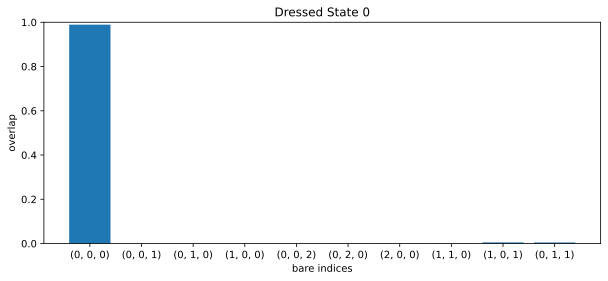

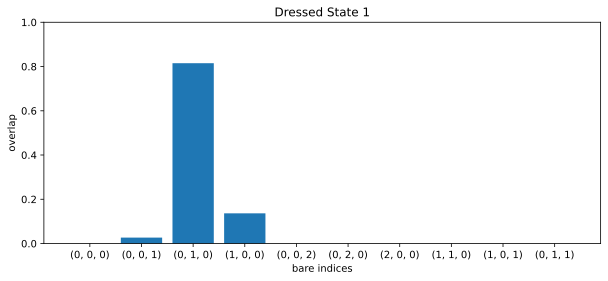

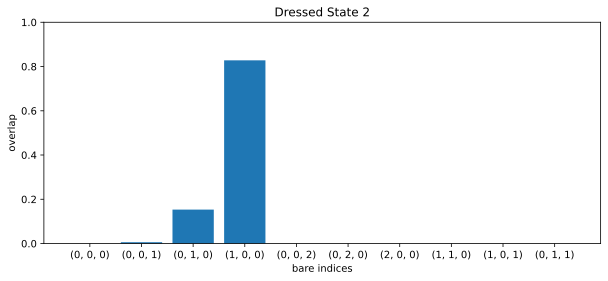

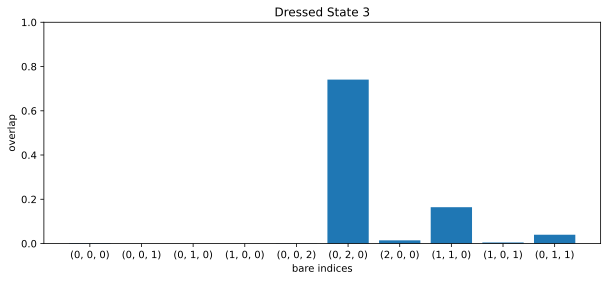

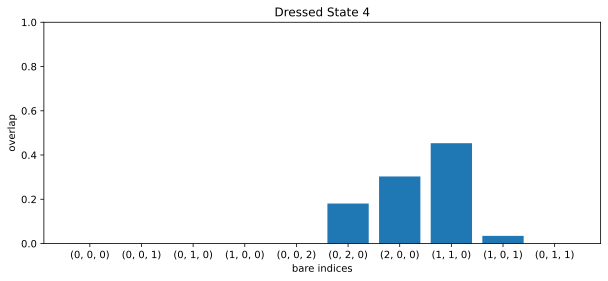

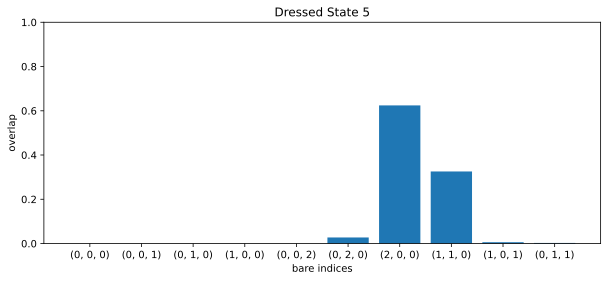

In [6]:
def plot_dressed_bare_overlaps():
    bare = [(0,0,0), (0,0,1), (0,1,0), (1,0,0), (0,0,2), (0,2,0), (2,0,0), (1,1,0), (1,0,1), (0,1,1)]
    labels = [str(j) for j in bare]
    
    for i in range(6):
        overlaps = []
        for bare_idx in bare:
            # print("overlap of dressed index ", i, " with bare index ", bare_idx)
            bare_state = system.bare_productstate(bare_idx)
            overlaps.append(abs(evecs[i].dag() * bare_state)**2)
    
        plt.figure(figsize=(10,4))
        plt.bar(labels, overlaps)
        plt.xlabel("bare indices")
        plt.ylabel("overlap")
        plt.title("Dressed State " + str(i))
        plt.ylim(0,1)
        plt.show()
plot_dressed_bare_overlaps()

Next, let's calculate the dressed and bare anharmonicities for the qubits and coupler.

In [7]:
def get_anharmonicities(evals, evecs, freqs):
    # dressed indices of each single-excitation state
    i1_tmon1  = system.dressed_index((1, 0, 0))
    i1_tmon2  = system.dressed_index((0, 1, 0))
    i1_coupler = system.dressed_index((0, 0, 1))

    # dressed indices of each double-excitation state
    i2_tmon1  = system.dressed_index((2, 0, 0))
    i2_tmon2  = system.dressed_index((0, 2, 0))
    i2_coupler  = system.dressed_index((0, 0, 2))

    E12_tmon1  = evals[i2_tmon1]  - evals[i1_tmon1]
    E12_tmon2  = evals[i2_tmon2]  - evals[i1_tmon2]
    E12_coupler  = evals[i2_coupler]  - evals[i1_coupler]

    return E12_tmon1-freqs[0], E12_tmon2-freqs[1], E12_coupler-freqs[2]
    
print("Bare anharmonicities:")
print(f"Tmon1:   {tmon1.anharmonicity():.4f}")
print(f"Tmon2:   {tmon2.anharmonicity():.4f}")
print(f"Coupler: {coupler.anharmonicity():.4f}")

tmon1_alpha, tmon2_alpha, coupler_alpha = get_anharmonicities(evals, evecs, get_E01_freqs(evals, evecs))
print("Dressed anharmonicities:")
print(f"Tmon1:   {tmon1_alpha:.4f}")
print(f"Tmon2:   {tmon2_alpha:.4f}")
print(f"Coupler: {coupler_alpha:.4f}")

Bare anharmonicities:
Tmon1:   -0.1978
Tmon2:   -0.1997
Coupler: -0.1438
Dressed anharmonicities:
Tmon1:   -0.1301
Tmon2:   -0.1278
Coupler: -0.1397


Both the bare and dressed anharmonicities are in the 100-200 MHz range, as expected.

Finally, we're ready to observe the behavior of the system as we vary the flux through the SQUID. Note $\phi_1 = \frac{\phi_\text{ext}}{\phi_0}$ where $\phi_0 = \frac{h}{2e}$ is the superconducting flux quantum.

In [8]:
scq.settings.OVERLAP_THRESHOLD = 0.4

100%|██████████| 40/40 [00:10<00:00,  3.84it/s]-packages\scqubits\utils\misc.py: 172


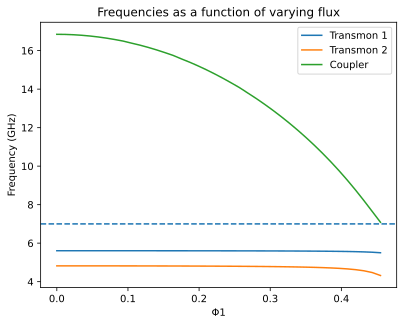

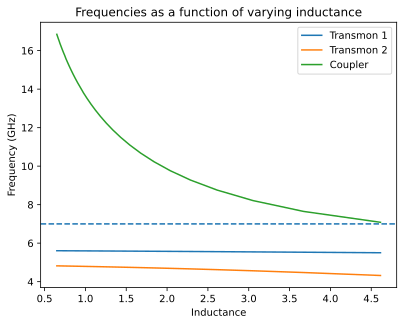

Coupler frequency reaches 7 GHz at Φ1 =  0.455


In [9]:
phi1_vals = np.linspace(0,0.455,40)

def get_coupling(w1, w2, w0):
    return np.abs(g12 + 0.5*g01*g02*(1/(w1-w0) + 1/(w2-w0)))

def sweep_phi1(phi1_vals):

    E01_tmon1_evo = []
    E01_tmon2_evo = []
    E01_coupler_evo = []

    tmon1_overlap = []
    tmon2_overlap = []
    coupler_overlap = []

    coupling=[]

    for phi1 in tqdm(phi1_vals):
        coupler.flux = phi1
        evals, evecs = system.eigensys(evals_count=50)
        system.generate_lookup()
        E01_tmon1, E01_tmon2, E01_coupler, overlaps = get_E01_freqs(evals, evecs, get_overlaps=True)
        g = get_coupling(E01_tmon1, E01_tmon2, E01_coupler)*10**3
        coupling.append(g)
        
        E01_tmon1_evo.append(E01_tmon1)
        E01_tmon2_evo.append(E01_tmon2)
        E01_coupler_evo.append(E01_coupler)
        
        tmon1_overlap.append(overlaps[0])
        tmon2_overlap.append(overlaps[1])
        coupler_overlap.append(overlaps[2])

    return E01_tmon1_evo, E01_tmon2_evo, E01_coupler_evo, tmon1_overlap, tmon2_overlap, coupler_overlap, coupling

E01_tmon1_evo, E01_tmon2_evo, E01_coupler_evo, tmon1_overlap, tmon2_overlap, coupler_overlap, coupling = sweep_phi1(phi1_vals)

plt.figure()
plt.plot(phi1_vals, E01_tmon1_evo, label='Transmon 1')
plt.plot(phi1_vals, E01_tmon2_evo, label='Transmon 2')
plt.plot(phi1_vals, E01_coupler_evo, label='Coupler')
plt.axhline(y=7,linestyle='dashed')
plt.xlabel("Φ1")
plt.ylabel("Frequency (GHz)")
plt.title("Frequencies as a function of varying flux")
plt.legend()
plt.show()

LJ0 = 0.65
LJ = LJ0 / np.cos(np.pi * phi1_vals)

plt.figure()
plt.plot(LJ, E01_tmon1_evo, label='Transmon 1')
plt.plot(LJ, E01_tmon2_evo, label='Transmon 2')
plt.plot(LJ, E01_coupler_evo, label='Coupler')
plt.axhline(y=7,linestyle='dashed')
plt.xlabel("Inductance")
plt.ylabel("Frequency (GHz)")
plt.title("Frequencies as a function of varying inductance")
plt.legend()
plt.show()

end_idx = np.argmin(np.abs(np.array(E01_coupler_evo)-7))
print("Coupler frequency reaches 7 GHz at Φ1 = ", phi1_vals[end_idx])

Above are plots of the dressed frequencies of the transmons and coupler plotted against the flux through the coupler SQUID and the coupler SQUID inductance, respectively. Note that the coupler frequency reaches 7 GHz at approximately $\phi_1$ = 0.455, so we restrict analysis to the range of $\phi_1$ values less than this.

Next, let's plot the qubit-qubit coupling.

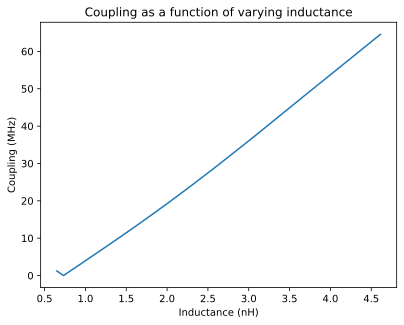

Qubit-qubit coupling is 0 at Φ1 = 0.152, L = 0.731 nH.
Maximum coupling is 64.6 MHz.


In [10]:
plt.figure()
plt.plot(LJ, coupling)
plt.xlabel("Inductance (nH)")
plt.ylabel("Coupling (MHz)")
plt.title("Coupling as a function of varying inductance")
plt.show()

coupling_off_idx = np.argmin(np.abs(np.array(coupling)))
print(f"Qubit-qubit coupling is 0 at Φ1 = {phi1_vals[coupling_off_idx]:.3f}, L = {LJ[coupling_off_idx]:.3f} nH.")
print(f"Maximum coupling is {coupling[-1]:.1f} MHz.")

Finally, if we look at hybridization of the eigenstates as the coupler frequency changes, we see the expected increase in hybridization as the coupler frequency approaches the qubit frequencies. We also see a few points where the hybridization of the coupler mode sharply increases.

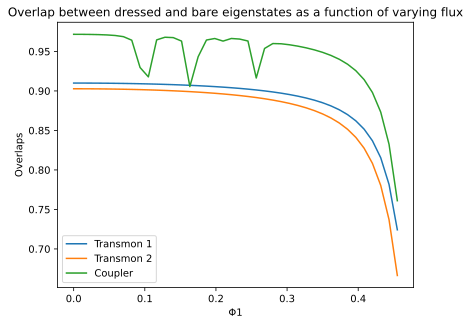

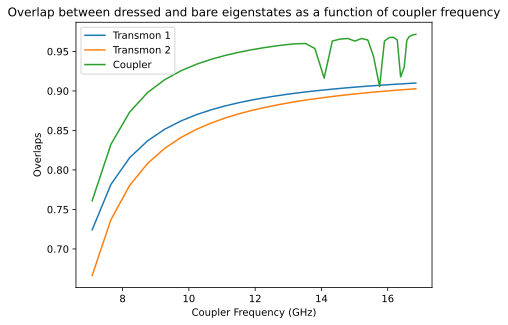

In [11]:
plt.figure()
plt.plot(phi1_vals, tmon1_overlap, label='Transmon 1')
plt.plot(phi1_vals, tmon2_overlap, label='Transmon 2')
plt.plot(phi1_vals, coupler_overlap, label='Coupler')
plt.xlabel("Φ1")
plt.ylabel("Overlaps")
plt.title("Overlap between dressed and bare eigenstates as a function of varying flux")
plt.legend()
plt.show()

plt.figure()
plt.plot(E01_coupler_evo, tmon1_overlap, label='Transmon 1')
plt.plot(E01_coupler_evo, tmon2_overlap, label='Transmon 2')
plt.plot(E01_coupler_evo, coupler_overlap, label='Coupler')
plt.xlabel("Coupler Frequency (GHz)")
plt.ylabel("Overlaps")
plt.title("Overlap between dressed and bare eigenstates as a function of coupler frequency")
plt.legend()
plt.show()

Where the peaks in coupler hybridization occur at frequencies that are resonant with multiples of higher qubit transitions.